## Assignment: Image recognition

The goals of the assignment are:
* Develop proficiency in using Tensorflow/Keras for training Neural Nets (NNs).
* Put into practice the acquired knowledge to optimize the parameters and architecture of a feedforward Neural Net (ffNN), in the context of an image recognition problem.
* Put into practice NNs specially conceived for analysing images. Design and optimize the parameters of a Convolutional Neural Net (CNN) to deal with previous task.
* Train popular architectures from scratch (e.g., GoogLeNet, VGG, ResNet, ...), and compare the results with the ones provided by their pre-trained versions using transfer learning.


In [63]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [64]:
import uuid
import numpy as np

class GenericObject:
    """
    Generic object data.
    """
    def __init__(self):
        self.id = uuid.uuid4()
        self.bb = (-1, -1, -1, -1)
        self.category= -1
        self.score = -1

class GenericImage:
    """
    Generic image data.
    """
    def __init__(self, filename):
        self.filename = filename
        self.tile = np.array([-1, -1, -1, -1])  # (pt_x, pt_y, pt_x+width, pt_y+height)
        self.objects = list([])

    def add_object(self, obj: GenericObject):
        self.objects.append(obj)

In [65]:
categories = {0: 'Cargo plane', 1: 'Small car', 2: 'Bus', 3: 'Truck', 4: 'Motorboat', 5: 'Fishing vessel', 6: 'Dump truck', 7: 'Excavator', 8: 'Building', 9: 'Helipad', 10: 'Storage tank', 11: 'Shipping container', 12: 'Pylon'}
# Crear mapas de nombre ↔ índice
category_to_index = {v: k for k, v in categories.items()}
index_to_category = {k: v for k, v in categories.items()}


##### Seed

In [66]:
import tensorflow as tf, numpy as np, random
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

In [ ]:
import os
import warnings
import rasterio

def load_geoimage(filename):
    warnings.filterwarnings('ignore', category=rasterio.errors.NotGeoreferencedWarning)

    # Normalize Windows/Linux path separators
    filename = filename.replace("/", os.sep).replace("\\", os.sep)

    # Base path: from the notebook, point to "Práctica/xview_recognition"
    base_dir = os.path.join(os.getcwd(), "Práctica", "xview_recognition")

    # Build full path
    filepath = os.path.join(base_dir, filename)

    if not os.path.exists(filepath):
        raise FileNotFoundError(f"El archivo no existe: {filepath}")

    # Open image and return it as a NumPy array
    with rasterio.open(filepath) as src:
        image = src.read()  # (bands, height, width)
        image = np.transpose(image, (1, 2, 0))  # (height, width, channels)

    return image.astype(np.float32)


#### Training
Design and train a ffNN to deal with the “xview_recognition” classification task.

In [68]:
import json

# Load database
json_file = "Práctica/xview_recognition/xview_ann_train.json"
with open(json_file) as ifs:
    json_data = json.load(ifs)
ifs.close()

In [69]:
import numpy as np

counts = dict.fromkeys(categories.values(), 0)
anns = []
for json_img, json_ann in zip(json_data['images'].values(), json_data['annotations'].values()):
    image = GenericImage(json_img['filename'])
    image.tile = np.array([0, 0, json_img['width'], json_img['height']])
    obj = GenericObject()
    obj.bb = (int(json_ann['bbox'][0]), int(json_ann['bbox'][1]), int(json_ann['bbox'][2]), int(json_ann['bbox'][3]))
    obj.category = json_ann['category_id']
    # Resampling strategy to reduce training time
    counts[obj.category] += 1
    image.add_object(obj)
    anns.append(image)
print(counts)

{'Cargo plane': 635, 'Small car': 3324, 'Bus': 1768, 'Truck': 2210, 'Motorboat': 1069, 'Fishing vessel': 706, 'Dump truck': 1236, 'Excavator': 789, 'Building': 3594, 'Helipad': 111, 'Storage tank': 1469, 'Shipping container': 1523, 'Pylon': 312}


In [70]:
import os, math, random
import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential, regularizers
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Activation, Flatten
from tensorflow.keras.optimizers import AdamW
from sklearn.utils.class_weight import compute_class_weight
import cv2

# Tamaño y batch
INPUT_SIZE = 64
BATCH_SIZE = 128
NUM_CLASSES = 13 

#### Object-by-object data preparation

In [71]:
objs = [(ann.filename, obj) for ann in anns for obj in ann.objects]

#### Category name normalizer

In [ ]:
def norm_cat(c: str) -> str:
    return str(c).strip().lower().replace(" ", "").replace("_", "").replace("-", "")

#### Map real categories to indices

In [ ]:
class_names = [categories[i] for i in sorted(categories.keys())]  
index_to_category = {i: categories[i] for i in sorted(categories.keys())}  
category_to_index = {name: idx for idx, name in index_to_category.items()}  
print(category_to_index)
print(index_to_category)

def norm_cat(s: str) -> str:
    return s.strip().lower().replace('-', ' ').replace('_', ' ')

alias_to_index = {norm_cat(name): idx for name, idx in category_to_index.items()}

def cat_to_idx(c: str):
    return category_to_index.get(c, alias_to_index.get(norm_cat(c)))


{'Cargo plane': 0, 'Small car': 1, 'Bus': 2, 'Truck': 3, 'Motorboat': 4, 'Fishing vessel': 5, 'Dump truck': 6, 'Excavator': 7, 'Building': 8, 'Helipad': 9, 'Storage tank': 10, 'Shipping container': 11, 'Pylon': 12}
{0: 'Cargo plane', 1: 'Small car', 2: 'Bus', 3: 'Truck', 4: 'Motorboat', 5: 'Fishing vessel', 6: 'Dump truck', 7: 'Excavator', 8: 'Building', 9: 'Helipad', 10: 'Storage tank', 11: 'Shipping container', 12: 'Pylon'}


#### Build the labels and groups

In [74]:
import numpy as np

y_idx = np.array([cat_to_idx(obj.category) for _, obj in objs], dtype=int)
groups = np.array([fn for fn, _ in objs])  # group = filename

#### Try StratifiedGroupKFold

In [75]:
from sklearn.model_selection import StratifiedGroupKFold
sgkf = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)
train_idx, valid_idx = next(sgkf.split(X=np.zeros(len(objs)), y=y_idx, groups=groups))


#### Build the final lists

In [76]:
objs_train = [objs[i] for i in train_idx]
objs_valid = [objs[i] for i in valid_idx]

#### Check for filename leakage

In [ ]:
train_fns = {fn for fn, _ in objs_train}
valid_fns = {fn for fn, _ in objs_valid}
leak = train_fns & valid_fns
print(f"Train objs: {len(objs_train)}  | Valid objs: {len(objs_valid)}")
print("Leak filenames:", len(leak))
assert len(leak) == 0, "There are images (filenames) shared between the training and validation sets!"

Train objs: 16871  | Valid objs: 1875
Leak filenames: 0


### Preprocessing

In [ ]:
def preprocess_image(img):
    img = cv2.resize(img, (INPUT_SIZE, INPUT_SIZE), interpolation=cv2.INTER_AREA)
    img = img.astype(np.float32) / 255.0
    return img



### Generator (produces X, y with indices, not one-hot encoded)

In [ ]:
from skimage.feature import hog
from skimage.color import rgb2gray

def extract_hog_features(img):
    """
    Recibe una imagen (64, 64, 3) normalizada.
    Devuelve un vector unidimensional de características HOG.
    """
    # 1. Convert to grayscale
    gray = rgb2gray(img)
    
    # 2. Compute HOG
    features = hog(gray, 
                   orientations=9, 
                   pixels_per_cell=(8, 8), 
                   cells_per_block=(2, 2), 
                   transform_sqrt=True, 
                   block_norm='L2-Hys', 
                   visualize=False, 
                   feature_vector=True)
    return features

In [ ]:
def generator_hog_images(objs, batch_size, do_shuffle=False):
    while True:
        if do_shuffle:
            random.shuffle(objs)

        batch_X, batch_y = [], []
        for filename, obj in objs:
            try:
                # 1. Load and perform basic preprocessing (resize to 64x64 + normalization)
                img = load_geoimage(filename)
                img = preprocess_image(img) 
                
                # 2. Extract HOG features (NEW STEP)
                hog_feat = extract_hog_features(img)

                # 3. Get the label index (same as before)
                raw = obj.category
                idx = category_to_index.get(raw)
                if idx is None:
                    idx = alias_to_index.get(norm_cat(raw))
                if idx is None:
                    continue  # Skip if there is no valid label

                batch_X.append(hog_feat)
                batch_y.append(idx)

                if len(batch_X) == batch_size:
                    yield np.array(batch_X, dtype=np.float32), np.array(batch_y, dtype=np.int32)
                    batch_X, batch_y = [], []
            except Exception as e:
                # Simple read error handling
                continue

In [ ]:
# Test with any image to check the vector size
sample_img = preprocess_image(load_geoimage(objs_train[0][0]))
sample_hog = extract_hog_features(sample_img)
HOG_INPUT_DIM = len(sample_hog)

print(f"Original dimensions: {sample_img.shape}")
print(f"New input dimension (HOG): {HOG_INPUT_DIM}")

Dimensión original: (64, 64, 3)
Nueva dimensión de entrada (HOG): 1764


### Class weights (from objs_train)

In [ ]:
# Build y_train (indices) from objs_train to compute weights
y_train_idx = []

for _, obj in objs_train:
    raw = obj.category
    idx = category_to_index.get(raw, alias_to_index.get(norm_cat(raw)))

    if idx is None:
        raise KeyError(f"Unmapped class in train: {raw}")

    y_train_idx.append(idx)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(category_to_index)),
    y=np.array(y_train_idx)
)

# Smoothing
class_weights = np.sqrt(class_weights)

class_weight_dict = {i: w for i, w in enumerate(class_weights)}

print("Class weights:", class_weight_dict)

Class weights: {0: 1.507581093809538, 1: 0.6585942610273532, 2: 0.9028741205831872, 3: 0.8077581433102843, 4: 1.161478568212552, 5: 1.4295912255178151, 6: 1.0803048925019718, 7: 1.351026713171712, 8: 0.6334739039640644, 9: 3.602456426897112, 10: 0.990793181073654, 11: 0.9729264474705284, 12: 2.152879492653992}


### Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization, Activation
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, RandomContrast

print('Load Optimized Model (BN + Dropout)')
model = Sequential()

# 1. Input layer
model.add(tf.keras.layers.InputLayer(input_shape=(HOG_INPUT_DIM,)))

# 2. Optimized Dense Blocks

# Block 1
model.add(Dense(2048, use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.4))

# Block 2
model.add(Dense(1024, use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.4))

# Block 3
model.add(Dense(512, use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.3))

# Block 4
model.add(Dense(256, use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.2))

# 3. Output layer
model.add(Dense(NUM_CLASSES, activation='softmax'))

model.summary()

Load Optimized Model (BN + Dropout)
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_5 (Dense)             (None, 2048)              3612672   
                                                                 
 batch_normalization_4 (Bat  (None, 2048)              8192      
 chNormalization)                                                
                                                                 
 activation_4 (Activation)   (None, 2048)              0         
                                                                 
 dropout_4 (Dropout)         (None, 2048)              0         
                                                                 
 dense_6 (Dense)             (None, 1024)              2097152   
                                                                 
 batch_normalization_5 (Bat  (None, 1024)              4096      
 chNormalization) 

### Optimizer

In [ ]:
from tensorflow.keras.optimizers import AdamW

optimizer = AdamW(learning_rate=0.0003, weight_decay=0.0)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name='top3_acc')  
    ]
)

### Callbacks

In [ ]:
from tensorflow.keras.callbacks import TerminateOnNaN, EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Callbacks
model_checkpoint = ModelCheckpoint(
    'model_complex.keras', 
    monitor='val_accuracy',   
    verbose=1, 
    save_best_only=True,
    mode='max'
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=10,
    verbose=1,
    mode='min'
)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    verbose=1,
    mode='min',
    restore_best_weights=True 
)
terminate = TerminateOnNaN()
callbacks = [model_checkpoint, reduce_lr, early_stop, terminate]

In [86]:
train_gen_hog = generator_hog_images(objs_train, BATCH_SIZE, do_shuffle=True)
valid_gen_hog = generator_hog_images(objs_valid, BATCH_SIZE, do_shuffle=False)

In [87]:
import math
import numpy as np

print('Training model')
epochs = 100
train_steps = math.ceil(len(objs_train)/BATCH_SIZE)
valid_steps = math.ceil(len(objs_valid)/BATCH_SIZE)
h =model.fit(
    train_gen_hog,
    steps_per_epoch=train_steps,
    validation_data=valid_gen_hog,
    validation_steps=valid_steps,
    epochs=epochs,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)
# Best validation model
best_idx = int(np.argmax(h.history['val_accuracy']))
best_value = np.max(h.history['val_accuracy'])
print('Best validation model: epoch ' + str(best_idx+1), ' - val_accuracy ' + str(best_value))

Training model
Epoch 1/100
132/132 [==============================] - ETA: 0s - loss: 1.9502 - accuracy: 0.3401 - top3_acc: 0.5965
Epoch 1: val_accuracy improved from -inf to 0.17240, saving model to model_complex.keras
132/132 [==============================] - 78s 558ms/step - loss: 1.9502 - accuracy: 0.3401 - top3_acc: 0.5965 - val_loss: 2.3666 - val_accuracy: 0.1724 - val_top3_acc: 0.3995 - lr: 3.0000e-04
Epoch 2/100
132/132 [==============================] - ETA: 0s - loss: 1.4151 - accuracy: 0.5030 - top3_acc: 0.7762
Epoch 2: val_accuracy improved from 0.17240 to 0.35833, saving model to model_complex.keras
132/132 [==============================] - 56s 424ms/step - loss: 1.4151 - accuracy: 0.5030 - top3_acc: 0.7762 - val_loss: 1.9102 - val_accuracy: 0.3583 - val_top3_acc: 0.6156 - lr: 3.0000e-04
Epoch 3/100
132/132 [==============================] - ETA: 0s - loss: 1.2075 - accuracy: 0.5680 - top3_acc: 0.8287
Epoch 3: val_accuracy improved from 0.35833 to 0.55833, saving model t

### Accuracy and loss plots

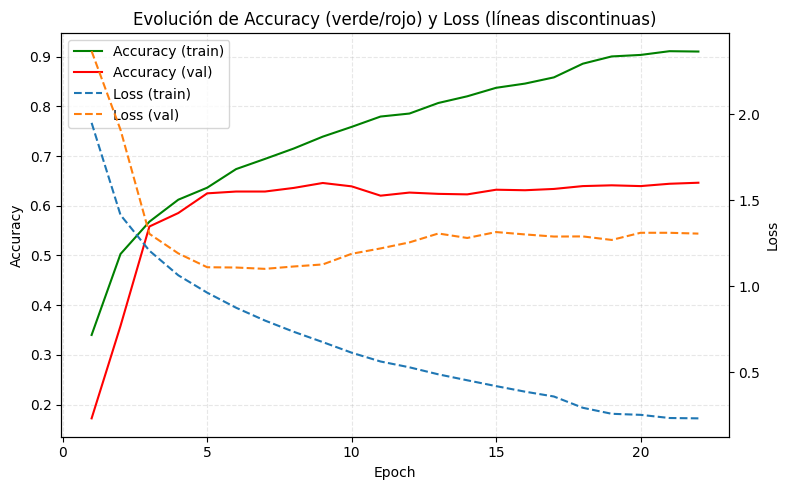

In [ ]:
import matplotlib.pyplot as plt

hist = h.history

# Detect accuracy keys (train/val)
acc_key = next((k for k in hist if 'acc' in k and not k.startswith('val_')), None)
val_acc_key = next((k for k in hist if k.startswith('val_') and 'acc' in k), None)

# Robust epoch range
num_epochs = len(next(iter(hist.values())))
epochs_range = range(1, num_epochs + 1)

fig, ax1 = plt.subplots(figsize=(8, 5))

# --- Accuracy (left axis) ---
lines = []
labels = []

if acc_key:
    l1, = ax1.plot(epochs_range, hist[acc_key], color='green', label=f'{acc_key}')
    lines.append(l1)
    labels.append('Accuracy (train)')

if val_acc_key:
    l2, = ax1.plot(epochs_range, hist[val_acc_key], color='red', label=f'{val_acc_key}')
    lines.append(l2)
    labels.append('Accuracy (val)')

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.grid(True, which='both', linestyle='--', alpha=0.3)

# --- Loss (right axis) ---
ax2 = ax1.twinx()

l3, = ax2.plot(epochs_range, hist['loss'], linestyle='--', label='loss')
lines.append(l3)
labels.append('Loss (train)')

if 'val_loss' in hist:
    l4, = ax2.plot(epochs_range, hist['val_loss'], linestyle='--', label='val_loss')
    lines.append(l4)
    labels.append('Loss (val)')

ax2.set_ylabel("Loss")

# Combined legend
ax1.legend(lines, labels, loc='best')

plt.title("Accuracy (green/red) and Loss (dashed lines) over epochs")
plt.tight_layout()
plt.show()

#### Validation
Compute validation metrics.

In [89]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

def draw_confusion_matrix(cm, categories):
    # Draw confusion matrix
    fig = plt.figure(figsize=[6.4*pow(len(categories), 0.5), 4.8*pow(len(categories), 0.5)])
    ax = fig.add_subplot(111)
    cm = cm.astype('float') / np.maximum(cm.sum(axis=1)[:, np.newaxis], np.finfo(np.float64).eps)
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.colormaps['Blues'])
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]), xticklabels=list(categories.values()), yticklabels=list(categories.values()), ylabel='Annotation', xlabel='Prediction')
    # Rotate the tick labels and set their alignment
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    # Loop over data dimensions and create text annotations
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], '.2f'), ha="center", va="center", color="white" if cm[i, j] > thresh else "black", fontsize=int(20-pow(len(categories), 0.5)))
    fig.tight_layout()
    plt.show()

In [ ]:
from skimage.feature import hog
from skimage.color import rgb2gray

def extract_hog_features(img):
    gray = rgb2gray(img)
    features = hog(gray, 
                   orientations=9, 
                   pixels_per_cell=(8, 8), 
                   cells_per_block=(2, 2), 
                   transform_sqrt=True, 
                   block_norm='L2-Hys', 
                   visualize=False, 
                   feature_vector=True)
    return features

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score

print(f"Evaluating on {len(objs_valid)} validation objects...")

y_true_val = []
y_pred_val = []

# Iterate directly over the validation list used by the model
for i, (filename, obj) in enumerate(objs_valid):
    # Log progress every 100 images
    if i % 100 == 0:
        print(f"Processing {i}/{len(objs_valid)}...", end='\r')

    try:
        img = load_geoimage(filename)
        img = preprocess_image(img)

        hog_features = extract_hog_features(img)

        hog_batch = hog_features.reshape(1, -1)
        predictions = model.predict(hog_batch, verbose=0)
        pred_idx = int(np.argmax(predictions, axis=-1)[0])
        y_pred_val.append(pred_idx)

        raw_cat = obj.category

        # Try to get the index directly or through the normalized alias
        true_idx = category_to_index.get(raw_cat)
        if true_idx is None:
            true_idx = alias_to_index.get(norm_cat(raw_cat))

        if true_idx is not None:
            y_true_val.append(true_idx)
        else:
            print(f"Warning: Category not found: {raw_cat}")

    except Exception as e:
        print(f"Error processing {filename}: {e}")
        continue

print(f"\nEvaluation completed. Total predictions: {len(y_pred_val)}")

Evaluando sobre 1875 objetos de validación...
Procesando 1800/1875...
Evaluación completada. Total predicciones: 1875


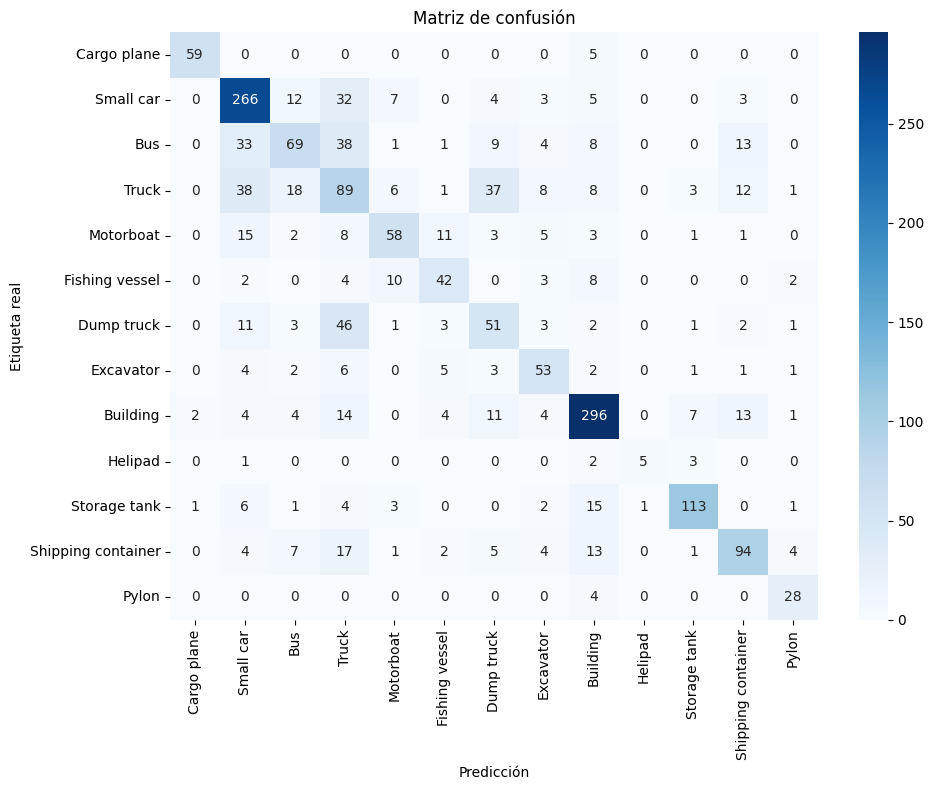

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

labels = list(range(len(class_names)))  # 0..N-1
cm = confusion_matrix(y_true_val, y_pred_val, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues"
)

plt.xlabel("Prediction")
plt.ylabel("True label")
plt.title("Confusion matrix")
plt.tight_layout()
plt.show()

In [98]:
import numpy as np

# Compute the accuracy
correct_samples_class = np.diag(cm).astype(float)
total_samples_class = np.sum(cm, axis=1).astype(float)
total_predicts_class = np.sum(cm, axis=0).astype(float)
print('Mean Accuracy: %.3f%%' % (np.sum(correct_samples_class) / np.sum(total_samples_class) * 100))
acc = correct_samples_class / np.maximum(total_samples_class, np.finfo(np.float64).eps)
print('Mean Recall: %.3f%%' % (acc.mean() * 100))
acc = correct_samples_class / np.maximum(total_predicts_class, np.finfo(np.float64).eps)
print('Mean Precision: %.3f%%' % (acc.mean() * 100))
for idx in range(len(categories)):
    # True/False Positives (TP/FP) refer to the number of predicted positives that were correct/incorrect.
    # True/False Negatives (TN/FN) refer to the number of predicted negatives that were correct/incorrect.
    tp = cm[idx, idx]
    fp = sum(cm[:, idx]) - tp
    fn = sum(cm[idx, :]) - tp
    tn = sum(np.delete(sum(cm) - cm[idx, :], idx))
    # True Positive Rate: proportion of real positive cases that were correctly predicted as positive.
    recall = tp / np.maximum(tp+fn, np.finfo(np.float64).eps)
    # Precision: proportion of predicted positive cases that were truly real positives.
    precision = tp / np.maximum(tp+fp, np.finfo(np.float64).eps)
    # True Negative Rate: proportion of real negative cases that were correctly predicted as negative.
    specificity = tn / np.maximum(tn+fp, np.finfo(np.float64).eps)
    # Dice coefficient refers to two times the intersection of two sets divided by the sum of their areas.
    # Dice = 2 |A∩B| / (|A|+|B|) = 2 TP / (2 TP + FP + FN)
    f1_score = 2 * ((precision * recall) / np.maximum(precision+recall, np.finfo(np.float64).eps))
    print('> %s: Recall: %.3f%% Precision: %.3f%% Specificity: %.3f%% Dice: %.3f%%' % (list(categories.values())[idx], recall*100, precision*100, specificity*100, f1_score*100))

Mean Accuracy: 65.227%
Mean Recall: 63.701%
Mean Precision: 67.340%
> Cargo plane: Recall: 92.188% Precision: 95.161% Specificity: 99.834% Dice: 93.651%
> Small car: Recall: 80.120% Precision: 69.271% Specificity: 92.353% Dice: 74.302%
> Bus: Recall: 39.205% Precision: 58.475% Specificity: 97.116% Dice: 46.939%
> Truck: Recall: 40.271% Precision: 34.496% Specificity: 89.782% Dice: 37.161%
> Motorboat: Recall: 54.206% Precision: 66.667% Specificity: 98.360% Dice: 59.794%
> Fishing vessel: Recall: 59.155% Precision: 60.870% Specificity: 98.503% Dice: 60.000%
> Dump truck: Recall: 41.129% Precision: 41.463% Specificity: 95.888% Dice: 41.296%
> Excavator: Recall: 67.949% Precision: 59.551% Specificity: 97.997% Dice: 63.473%
> Building: Recall: 82.222% Precision: 79.784% Specificity: 95.050% Dice: 80.985%
> Helipad: Recall: 45.455% Precision: 83.333% Specificity: 99.946% Dice: 58.824%
> Storage tank: Recall: 76.871% Precision: 86.923% Specificity: 99.016% Dice: 81.588%
> Shipping container:

#### Testing


In [93]:
import os
import numpy as np

anns = []
for (dirpath, dirnames, filenames) in os.walk('Práctica/xview_recognition/xview_test'):
    for filename in filenames:
        image_rel = os.path.relpath(dirpath, 'Práctica/xview_recognition')
        image = GenericImage(os.path.join(image_rel, filename))
        image.tile = np.array([0, 0, 224, 224])
        obj = GenericObject()
        obj.bb = (0, 0, 224, 224)
        obj.category = dirpath[dirpath.rfind('/')+1:]
        image.add_object(obj)
        anns.append(image)
print('Number of testing images: ' + str(len(anns)))

Number of testing images: 2365


##### Generate predictions

In [ ]:
import os
import numpy as np

model.load_weights('model_complex.keras')
predictions_data = {"images": {}, "annotations": {}}

for idx, ann in enumerate(anns):
    filename = os.path.basename(ann.filename)  # <- filename only, without the path
    image_data = {
        "image_id": filename,
        "filename": ann.filename,
        "width": int(ann.tile[2]),
        "height": int(ann.tile[3])
    }
    predictions_data["images"][idx] = image_data

    # Load image
    image = load_geoimage(ann.filename)
    image = preprocess_image(image)

    for obj_pred in ann.objects:
        # Generate prediction
        hog_features = extract_hog_features(image)
        hog_batch = hog_features.reshape(1, -1)
        predictions = model.predict(hog_batch, verbose=0)

        # Save prediction
        pred_category = int(np.argmax(predictions, axis=-1)[0])
        pred_score = np.max(predictions)

        annotation_data = {
            "image_id": filename,
            "category_id": pred_category,
            "bbox": [int(x) for x in obj_pred.bb]
        }

        predictions_data["annotations"][idx] = annotation_data

##### Generamos el json para la competición

In [103]:
with open("prediction.json", "w") as outfile:
    json.dump(predictions_data, outfile)